In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import decode_matlab_strings, load_img_natraster, TimeSeries, dRSA, get_relevant_output_layers
from general_utils.II import dynInformationImbalance
from image_processing.computational_models import map_image_order_from_ann_to_monkey


In [17]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'three0' #'paul'
    date: str =  '250313' #'230204'
    img_size = 384
    folder_name = 'talia_20each_tizi' # 'fewer_occlusion'
    new_fs = 100
    RDM_metric_signal = 'cosine'
    RDM_metric_model = 'cosine'
    model_name = 'vit_l_16'
    pkg = 'timm'
    img_size = 384
    pooling = 'mean'
    layer_name = 'blocks.1.mlp.fc2'
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

In [3]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [4]:
dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"), 
    allow_empty=True, 
)



In [5]:
idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)

In [6]:
ba_raster = TimeSeries(raster.get_array()[:20,:, :], raster.get_fs())

In [18]:
drsa_obj = dRSA(cfg.RDM_metric_signal, cfg.RDM_metric_model)
drsa_obj.compute_RDM_timeseries(ba_raster, "signal")
dyn_ii_obj = dynInformationImbalance(cfg.RDM_metric_signal, cfg.RDM_metric_model)
dyn_ii_obj.set_RDM_timeseries(drsa_obj.get_RDM_timeseries("signal"), "signal")
dyn_ii_obj.compute_distance_ranks_timeseries("signal")



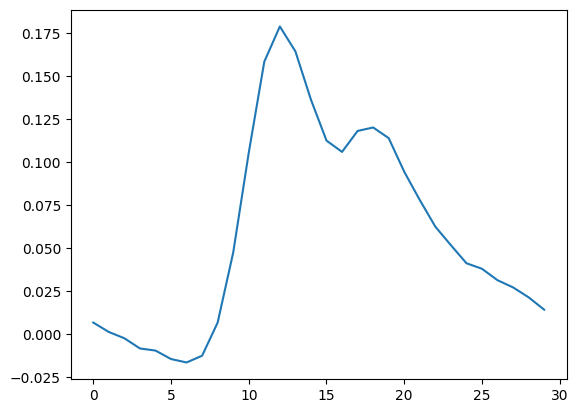

In [19]:
ba_raster.to_numpy()
plt.plot(np.mean(ba_raster.get_array(), axis=(0,2)))

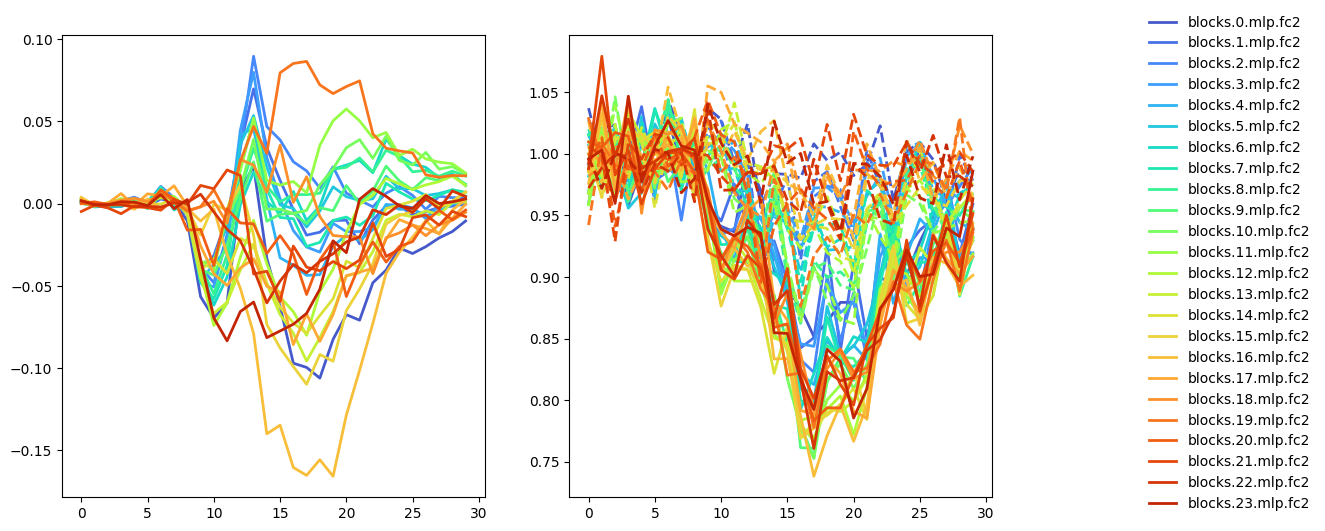

In [20]:
from general_utils.plots import truncate_colormap
base_cmap = plt.cm.turbo
cmap = truncate_colormap(base_cmap, 0.10, 0.90)
perm = np.random.permutation(len(idx_ord))
fig, ax = plt.subplots(1,2, figsize=(12, 6))
for i_col, l in enumerate(layers):
    try:
        color = cmap(i_col / (len(layers) - 1))
        feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_{l}_features_{cfg.pooling}pool.npz"
        features = np.load(feats_filename)["arr_0"][:, idx_ord]
        drsa_obj.compute_RDM(features, "model")
        drsa = drsa_obj.compute_static_dRSA()
        ax[0].plot(drsa.get_array(), color=color, label=l, linewidth=2)
        dyn_ii_obj.set_RDM(drsa_obj.get_RDM("model"), "model")
        dyn_ii_obj.compute_distance_ranks("model")
        dyn_ii = dyn_ii_obj.compute_both_static_dynII()
        ax[1].plot(dyn_ii[0].get_array(), color=color, linewidth=2, linestyle="--")
        ax[1].plot(dyn_ii[1].get_array(), color=color, linewidth=2)
    except FileNotFoundError:
        pass
fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
);